In [ ]:
import jax
jax.config.update("jax_platform_name", "cpu")
import jax.numpy as jnp

from functools import partial
import matplotlib.pyplot as plt

from jax.scipy.sparse.linalg import cg

print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

In [ ]:
import croissant as cro
import croissant.jax as crojax
from healpy import get_nside, projview, ud_grade, Alm
import lunarsky
import numpy as np
import s2fft
import astropy
import astropy.units as u
from tqdm import tqdm

In [8]:
print(freq)

[5.00e+07 5.10e+07 5.20e+07 5.30e+07 5.40e+07 5.50e+07 5.60e+07 5.70e+07
 5.80e+07 5.90e+07 6.00e+07 6.10e+07 6.20e+07 6.30e+07 6.40e+07 6.50e+07
 6.60e+07 6.70e+07 6.80e+07 6.90e+07 7.00e+07 7.10e+07 7.20e+07 7.30e+07
 7.40e+07 7.50e+07 7.60e+07 7.70e+07 7.80e+07 7.90e+07 8.00e+07 8.10e+07
 8.20e+07 8.30e+07 8.40e+07 8.50e+07 8.60e+07 8.70e+07 8.80e+07 8.90e+07
 9.00e+07 9.10e+07 9.20e+07 9.30e+07 9.40e+07 9.50e+07 9.60e+07 9.70e+07
 9.80e+07 9.90e+07 1.00e+08 1.01e+08 1.02e+08 1.03e+08 1.04e+08 1.05e+08
 1.06e+08 1.07e+08 1.08e+08 1.09e+08 1.10e+08 1.11e+08 1.12e+08 1.13e+08
 1.14e+08 1.15e+08 1.16e+08 1.17e+08 1.18e+08 1.19e+08 1.20e+08 1.21e+08
 1.22e+08 1.23e+08 1.24e+08 1.25e+08 1.26e+08 1.27e+08 1.28e+08 1.29e+08
 1.30e+08 1.31e+08 1.32e+08 1.33e+08 1.34e+08 1.35e+08 1.36e+08 1.37e+08
 1.38e+08 1.39e+08 1.40e+08 1.41e+08 1.42e+08 1.43e+08 1.44e+08 1.45e+08
 1.46e+08 1.47e+08 1.48e+08 1.49e+08 1.50e+08 1.51e+08 1.52e+08 1.53e+08
 1.54e+08 1.55e+08 1.56e+08 1.57e+08 1.58e+08 1.59e

In [9]:
print(freq2)

[5.00e+07 5.10e+07 5.20e+07 5.30e+07 5.40e+07 5.50e+07 5.60e+07 5.70e+07
 5.80e+07 5.90e+07 6.00e+07 6.10e+07 6.20e+07 6.30e+07 6.40e+07 6.50e+07
 6.60e+07 6.70e+07 6.80e+07 6.90e+07 7.00e+07 7.10e+07 7.20e+07 7.30e+07
 7.40e+07 7.50e+07 7.60e+07 7.70e+07 7.80e+07 7.90e+07 8.00e+07 8.10e+07
 8.20e+07 8.30e+07 8.40e+07 8.50e+07 8.60e+07 8.70e+07 8.80e+07 8.90e+07
 9.00e+07 9.10e+07 9.20e+07 9.30e+07 9.40e+07 9.50e+07 9.60e+07 9.70e+07
 9.80e+07 9.90e+07 1.00e+08 1.01e+08 1.02e+08 1.03e+08 1.04e+08 1.05e+08
 1.06e+08 1.07e+08 1.08e+08 1.09e+08 1.10e+08 1.11e+08 1.12e+08 1.13e+08
 1.14e+08 1.15e+08 1.16e+08 1.17e+08 1.18e+08 1.19e+08 1.20e+08 1.21e+08
 1.22e+08 1.23e+08 1.24e+08 1.25e+08 1.26e+08 1.27e+08 1.28e+08 1.29e+08
 1.30e+08 1.31e+08 1.32e+08 1.33e+08 1.34e+08 1.35e+08 1.36e+08 1.37e+08
 1.38e+08 1.39e+08 1.40e+08 1.41e+08 1.42e+08 1.43e+08 1.44e+08 1.45e+08
 1.46e+08 1.47e+08 1.48e+08 1.49e+08 1.50e+08 1.51e+08 1.52e+08 1.53e+08
 1.54e+08 1.55e+08 1.56e+08 1.57e+08 1.58e+08 1.59e

In [12]:
bowtie['bm'].shape

(202, 49152)

In [27]:
beams = []
bowtie = jnp.load('eigsep_bowtie_v000.npz')
beams.append(bowtie['bm'][:-1])
vivaldi = jnp.load('eigsep_vivaldi.npz')
freq = vivaldi['freqs']
beams.append(vivaldi['bm'])
nside = vivaldi['nside'].item()
beams = jnp.array(beams)

In [29]:
lmax = 2*nside
#freq = jnp.arange(51,101)  # MHz
ntimes = 500
world = "earth"
total_beam_num = len(beams)

beam_alms = []
norms = []
beam2alm = partial(s2fft.forward_jax, L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True)
for beam in beams:
    # plt.figure()
    # plt.imshow(beam[0], aspect="auto")
    # plt.colorbar()
    # plt.show()
    
    beam_alm = jax.vmap(beam2alm)(beam)  # computes alm of beam
    norm = crojax.alm.total_power(beam_alm, lmax)

    beam_alms.append(beam_alm)
    norms.append(norm)
beam_alms = jnp.array(beam_alms)
norms = jnp.array(norms)

# coefficients for rotating the sky
dt = cro.constants.sidereal_day[world] / ntimes
phases = crojax.simulator.rot_alm_z(lmax, ntimes, dt, world=world)

In [30]:
time = astropy.time.Time("2025-12-01 09:00:00")
loc = astropy.coordinates.EarthLocation(lon=0, lat=45)
topo = astropy.coordinates.AltAz(obstime=time, location=loc)

eul_topo, dl_topo = crojax.rotations.generate_euler_dl(lmax, topo, "fk5")
eul_gal, dl_gal = crojax.rotations.generate_euler_dl(lmax, "galactic", "fk5")

topo2fk5 = partial(s2fft.utils.rotation.rotate_flms, L=lmax+1, rotation=eul_topo, dl_array=dl_topo)
gal2fk5 = partial(s2fft.utils.rotation.rotate_flms, L=lmax+1, rotation=eul_gal, dl_array=dl_gal)

In [31]:
def load_true_sky(realistic=False):
    sky_lmax = lmax
    sky_L = sky_lmax + 1
    nside = sky_L // 2  # nside has to be power of 2 so make it largest power of two less than this
    if realistic:
        sky_map = np.load("gsm_model.npy")
        original_nside = get_nside(sky_map[0]) 
        if nside != original_nside:
            sky_map = ud_grade(sky_map, nside)
        sky_map = jnp.array(sky_map)
        #sky_map = sky_map - jnp.mean(sky_map, axis=0, keepdims=True)
        sky2alm = partial(s2fft.forward_jax, L=sky_L, spin=0, nside=nside, sampling="healpix", reality=True)
        sky_alm = jax.vmap(sky2alm)(sky_map) # XXX, compute the spherical harmonics decomposition
        #sky_alm = sky_alm.at[:, 10:, :].set(0)
        sky_alm = jax.vmap(gal2fk5)(sky_alm)
        return sky_alm
    else:
        sky_alm = jnp.zeros((freq.size, sky_lmax+1, 2*sky_lmax+1))
        sky_alm = sky_alm.at[:, 0, sky_lmax].set((freq)**(-2.5))
        sky_alm = sky_alm.at[:, 1, sky_lmax].set((freq)**(-2.5) / 2)
        sky_alm = sky_alm.at[:, 2, sky_lmax].set((freq)**(-2.5) / 3)
        
        sky_alm = sky_alm.at[:, 3, sky_lmax-1].set(-1*jnp.conjugate((freq)**(-2.5)  * 5 * (1+1j)))
        sky_alm = sky_alm.at[:, 3, sky_lmax+1].set((freq)**(-2.5) * 5 * (1 + 1j))
        sky_alm = sky_alm.at[:, 4, sky_lmax-1].set(-1*jnp.conjugate((freq)**(-2.5) / 1 * (1+1j)))
        sky_alm = sky_alm.at[:, 4, sky_lmax+1].set((freq)**(-2.5) / 1 * (1 + 1j))
        sky_alm = sky_alm.at[:, 5, sky_lmax-1].set(-1*jnp.conjugate((freq)**(-2.5) / 1 * (1+1j)))
        sky_alm = sky_alm.at[:, 5, sky_lmax+1].set((freq)**(-2.5) / 1 * (1 + 1j))

    return sky_alm * 1e5


true_sky_alm = load_true_sky(realistic = True)

In [32]:
beam_alms_transformed = []
for beam_alm in beam_alms:
    beam_alm = jax.vmap(topo2fk5)(beam_alm)
    beam_alms_transformed.append(beam_alm)
beam_alms_transformed = jnp.array(beam_alms_transformed)

In [33]:
print(jnp.shape(beam_alms_transformed), jnp.shape(true_sky_alm))

(2, 201, 129, 257) (50, 129, 257)


In [34]:
IX = 10
beam_alms_f = beam_alms_transformed[:, IX, :, :]
norm_f = norms[:, IX]
true_sky_alm_f = true_sky_alm[IX]

@jax.jit
def forward_onefreq(sky_alm_f):
    """
    sky_alm_f: complex array (L, M) for one frequency
    returns: real vis (T, B) (or whatever your convolve returns)
    """
    vis = crojax.simulator.convolve(beam_alms_f, sky_alm_f[None], phases) / norm_f
    return jnp.squeeze(vis).real  # match your prior waterfall convention

@jax.jit
def forward_onefreq_beam(sky_alm_f, b):
    vis = crojax.simulator.convolve(beam_alms_f[b][None], sky_alm_f, phases) / norm_f[b][None]
    return jnp.squeeze(vis).real

In [35]:
beam_alms_f[0].shape

(129, 257)

In [36]:
twod_shape = (lmax+1, 2*lmax+1)
oned_shape = 2 * Alm.getsize(lmax) - (lmax+1)

In [ ]:
# Precompute index arrays for vectorized pack/unpack (no Python loops at trace time)
def _build_alm_indices(lmax):
    rows, cols_pos, cols_neg, signs = [], [], [], []
    for m in range(1, lmax + 1):
        for l in range(m, lmax + 1):
            rows.append(l)
            cols_pos.append(lmax + m)
            cols_neg.append(lmax - m)
            signs.append((-1.0)**m)
    return (jnp.array(rows), jnp.array(cols_pos),
            jnp.array(cols_neg), jnp.array(signs))

_alm_rows, _alm_cols_pos, _alm_cols_neg, _alm_signs = _build_alm_indices(lmax)
_N_pos_m = len(_alm_rows)


def _unpack_single_freq(x_freq, lmax):
    """Vectorized: 1D real vector -> 2D complex s2fft alm array."""
    m0_real = x_freq[:lmax + 1]
    pos_m_real = x_freq[lmax + 1 : lmax + 1 + _N_pos_m]
    pos_m_imag = x_freq[lmax + 1 + _N_pos_m:]
    pos_m_complex = (1 / jnp.sqrt(2)) * (pos_m_real + 1j * pos_m_imag)

    flm = jnp.zeros((lmax + 1, 2 * lmax + 1), dtype=jnp.complex128)
    flm = flm.at[:, lmax].set(m0_real + 0j, unique_indices=True)
    flm = flm.at[_alm_rows, _alm_cols_pos].set(pos_m_complex, unique_indices=True)
    flm = flm.at[_alm_rows, _alm_cols_neg].set(_alm_signs * jnp.conj(pos_m_complex), unique_indices=True)
    return flm


def _pack_single_freq(flm_freq, lmax):
    """Vectorized: 2D complex s2fft alm array -> 1D real vector."""
    m0_real = jnp.real(flm_freq[:, lmax])
    pos_m_complex = jnp.sqrt(2) * flm_freq[_alm_rows, _alm_cols_pos]
    return jnp.concatenate([m0_real, jnp.real(pos_m_complex), jnp.imag(pos_m_complex)])


def s2fft_unravel_onefreq(x_real, lmax, Nfreq=1):
    N_per_freq = (lmax + 1)**2
    x_reshaped = jnp.ravel(x_real).reshape(Nfreq, N_per_freq)
    return jax.vmap(_unpack_single_freq, in_axes=(0, None))(x_reshaped, lmax)


def s2fft_ravel_onefreq(flm_s2fft):
    Nfreq, L, _ = flm_s2fft.shape
    lmax = L - 1
    return jnp.ravel(jax.vmap(_pack_single_freq, in_axes=(0, None))(flm_s2fft, lmax))

print(f"Index arrays built: {_N_pos_m} entries for lmax={lmax}")

In [ ]:
# Pure JAX forward/adjoint model — no scipy LinearOperator, no numpy round-trips

@jax.jit
def forward_all(x):
    """Packed real alm (16641,) -> visibilities (1000,) for all beams."""
    sky_alm = _unpack_single_freq(x, lmax)  # (L, M) complex
    vis = jnp.einsum("lm,tm,blm->tb", sky_alm.conjugate(), phases, beam_alms_f)
    vis = vis.real / norm_f[None, :]  # (T, B)
    return vis.T.ravel()  # (B*T,): beam0 then beam1

# Automatic adjoint via JAX transposition
_x0 = jnp.zeros(oned_shape)
_adjoint_fn = jax.linear_transpose(forward_all, _x0)

@jax.jit
def adjoint_all(y):
    """Visibilities (1000,) -> packed real alm (16641,)."""
    return _adjoint_fn(y)[0]

# Verify shapes and trigger JIT compilation
_test_fwd = forward_all(jnp.zeros(oned_shape))
_test_adj = adjoint_all(jnp.zeros(total_beam_num * ntimes))
print("forward_all:", _test_fwd.shape, "adjoint_all:", _test_adj.shape)

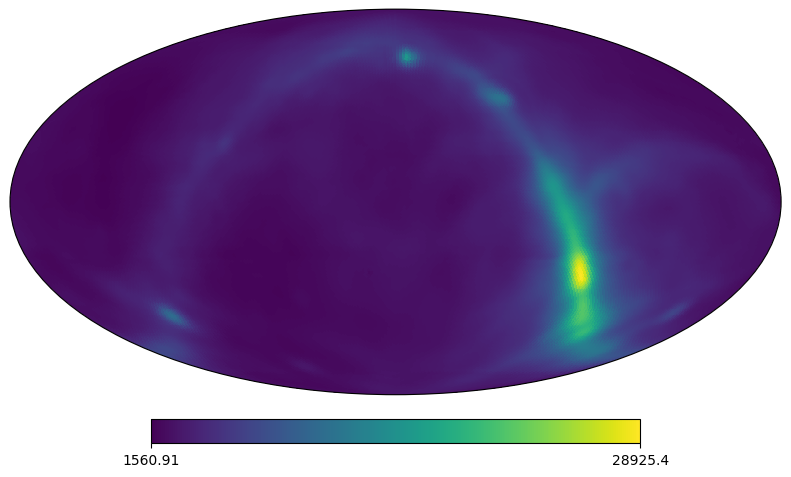

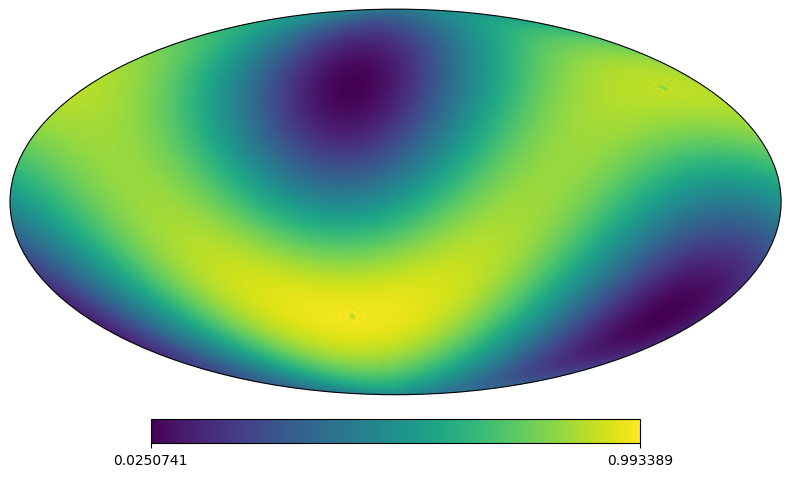

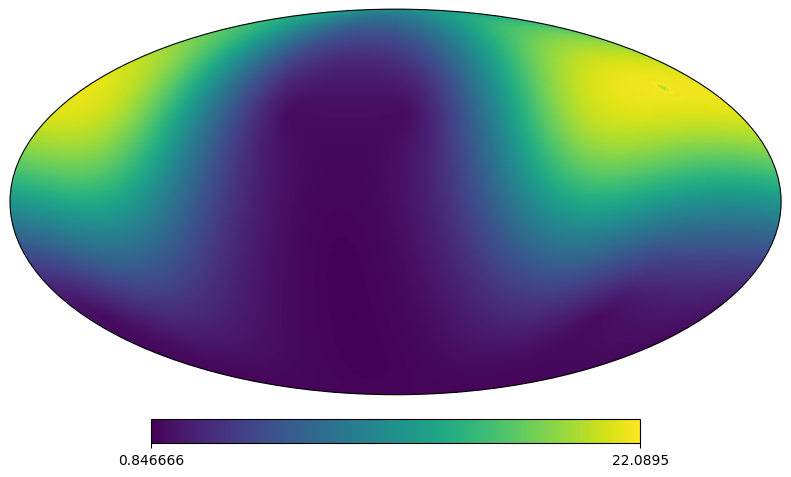

In [40]:
original_skymap_0 = s2fft.inverse_jax(true_sky_alm[IX], L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True).real
projview(original_skymap_0)

# what the beam looks like in equatorial
for beam_alm in beam_alms_transformed:
    beam_eq = s2fft.inverse_jax(beam_alm[IX], L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True).real
    projview(beam_eq)


In [41]:
times = time + jnp.arange(ntimes) * dt * u.s
print(times[0], times[-1])

2025-12-01 09:00:00.000 2025-12-02 08:53:11.872


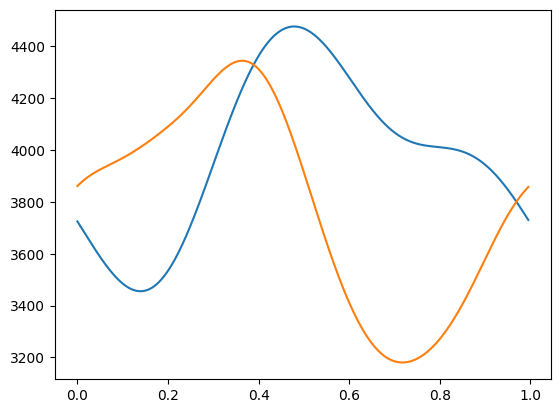

In [42]:
y_true = forward_onefreq(true_sky_alm_f)
plt.plot(times.jd-times.jd[0], y_true)

In [ ]:
# Verify forward_all matches original forward_onefreq
y_check = forward_all(s2fft_ravel_onefreq(true_sky_alm_f[None]))
y_orig = forward_onefreq(true_sky_alm_f)
# forward_onefreq returns (T, B), forward_all returns (B*T,)
print("Max difference:", float(jnp.max(jnp.abs(y_check.reshape(total_beam_num, ntimes).T - y_orig))))

In [ ]:
y_true = forward_all(s2fft_ravel_onefreq(true_sky_alm_f[None]))
vis = y_true.reshape(total_beam_num, ntimes).T

plt.figure()
plt.plot(times.jd - times.jd[0], vis)
plt.show()

plt.figure()
plt.plot(y_true)
plt.show()

In [47]:
df = 1e6 *(freq[1] - freq[0])
dt = (times.jd[1] - times.jd[0]) * 24 * 3600
sigma = y_true / jnp.sqrt(df * dt)
Ndiag = sigma**2

In [ ]:
# like the LuSEE paper
true_ra = s2fft_ravel_onefreq(true_sky_alm_f[None])
C_LN = jnp.abs(true_ra)**2
S_diag = jnp.array(C_LN)

print("S_diag shape:", S_diag.shape)

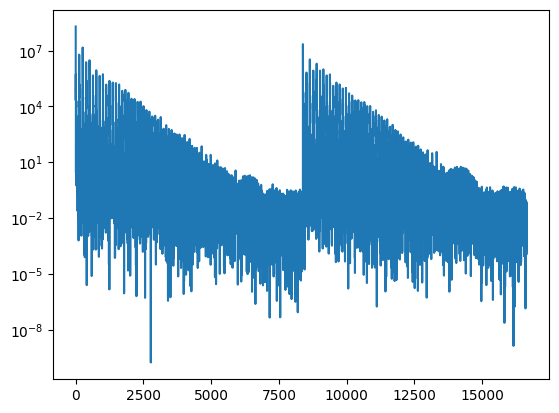

In [50]:
plt.figure()
plt.plot((S_diag))
plt.yscale("log")
plt.show()

In [ ]:
# Wiener filter via CG: solve (A S A^H + N) x = y, then m = S A^H x

@jax.jit
def matvec_M(x):
    """Compute (A S A^H + N) x — one CG iteration."""
    return forward_all(S_diag * adjoint_all(x)) + Ndiag * x

x_sol, info = jax.scipy.sparse.linalg.cg(matvec_M, y_true, tol=1e-6, maxiter=1000)
print("CG info:", info)

# Recover the Wiener-filtered map estimate
m = S_diag * adjoint_all(x_sol)

In [ ]:
y_guess = forward_all(m)

In [ ]:
print("||y_true||:", float(jnp.linalg.norm(y_true)))
print("||y_guess ||:", float(jnp.linalg.norm(y_guess)))
print("rel err  :", float(jnp.sqrt(jnp.linalg.norm(y_guess - y_true)/jnp.linalg.norm(y_true))))

In [ ]:
plt.figure()
vis = y_true.reshape(total_beam_num, ntimes).T
plt.plot(times.jd-times.jd[0], vis)
vis2 = y_guess.reshape(total_beam_num, ntimes).T
plt.plot(times.jd-times.jd[0], vis2, ls="--")
#plt.ylim(60, 70)
plt.show()

In [ ]:
sky_guess = s2fft_unravel_onefreq(m, lmax)

original_skymap_0 = s2fft.inverse_jax(true_sky_alm[IX], L=beam_L, spin=0, nside=16, sampling="healpix", reality=True).real
guess_skymap_0 = s2fft.inverse_jax(sky_guess[0], L=beam_L, spin=0, nside=16, sampling="healpix", reality=True).real
projview(original_skymap_0, min=0, max=1e4)
projview(guess_skymap_0, min=0, max=1e4)

## to do first:

try different S matrix(look online/in paper) \
more times to get ntimes to be similar order of magnitude to m.shape \
try different beams \
multiple frequencies at once \
add horizon to the beam 


later on:

multiple beams at once \
eigsep data?

multiple beams at once(beam_alm1, beam_alm2)
in forward_onefreq, vis1, vis2, etc. for each beam. return vis the jnp.concatenate of each of these vis


bowtie and revaldi beam after